In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import spearmanr, ttest_rel, zscore
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, "/data/lea_schmitt/multiarrangement")

from rsatools import compute_rdm_from_meadows

In [2]:
def rdm_to_vector(rdm: np.ndarray) -> np.ndarray:
    """Return upper-triangular RDM entries (without diagonal)."""
    return rdm[np.triu_indices_from(rdm, k=1)]


def build_similarity_matrix(vectors: list[np.ndarray]) -> np.ndarray:
    """Compute participant-by-participant Spearman similarity matrix."""
    n = len(vectors)
    sim = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            sim[i, j] = spearmanr(vectors[i], vectors[j]).correlation
    return sim


def load_rdm_data_from_disk() -> tuple[list[np.ndarray], list[str]]:
    """Load participant RDMs and filenames from the configured RDM output folder."""
    rdm_files = sorted(
        [
            os.path.join(OUTPUT_PATH_RDMS, f)
            for f in os.listdir(OUTPUT_PATH_RDMS)
            if f.endswith("_rdm.csv") and "mean_behavior" not in f
        ]
    )
    if not rdm_files:
        raise FileNotFoundError(
            f"No participant *_rdm.csv files found in {OUTPUT_PATH_RDMS}. Run the RDM generation cells first."
        )

    rdms = [pd.read_csv(path, index_col=0).values for path in rdm_files]
    files = [os.path.basename(path).replace("_rdm.csv", ".csv") for path in rdm_files]
    return rdms, files


def p_to_stars(p: float) -> str:
    """Map p-values to significance stars."""
    if pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def mean_ci(
    df: pd.DataFrame,
    condition: str,
    cls: str,
    value_col: str = "dissimilarity",
    condition_col: str = "condition",
    class_col: str = "letter_class",
) -> tuple[float, float]:
    """Return mean and 95% CI half-width for a condition x class subset."""
    vals = df.loc[
        (df[condition_col] == condition) & (df[class_col] == cls),
        value_col,
    ]
    if len(vals) < 2:
        return (vals.mean() if len(vals) else np.nan), 0.0
    return vals.mean(), 1.96 * vals.std() / np.sqrt(len(vals))


def pair_distance(rdm: np.ndarray, stim_to_idx: dict[str, int], stim_a: str, stim_b: str) -> float:
    """Return pairwise dissimilarity from an RDM by stimulus labels."""
    return float(rdm[stim_to_idx[stim_a], stim_to_idx[stim_b]])

In [27]:
# Central configuration used across the notebook
DATA_PATH = os.path.join("behavioral_data")
DATA_PATH_EXCL = os.path.join("behavioral_data/for_now_excluded")
OUTPUT_PATH_RDMS = os.path.join("rdms/behavior")
OUTPUT_PATH_FIGS = os.path.join("figures/behavior")

ORDER = [
    # Letters with 3 variants (normal, large, rot90)
    "b_normal", "b_large", "b_normal_rot90",
    "d_normal", "d_large", "d_normal_rot90",
    "q_normal", "q_large", "q_normal_rot90",
    "p_normal", "p_large", "p_normal_rot90",
    # Letters with 5 variants (normal, large, flip_h, flip_v, rot90)
    "r_normal", "r_large", "r_normal_flip_h", "r_normal_flip_v", "r_normal_rot90",
    "a_normal", "a_large", "a_normal_flip_h", "a_normal_flip_v", "a_normal_rot90",
    "e_normal", "e_large", "e_normal_flip_h", "e_normal_flip_v", "e_normal_rot90",
    "f_normal", "f_large", "f_normal_flip_h", "f_normal_flip_v", "f_normal_rot90",
    "h_normal", "h_large", "h_normal_flip_h", "h_normal_flip_v", "h_normal_rot90",
    "k_normal", "k_large", "k_normal_flip_h", "k_normal_flip_v", "k_normal_rot90",
]


horizontal_pairs = [
    # reversible pairs
    ("reversible", "b↔d", "b_normal", "d_normal"),
    ("reversible", "b↔d", "b_large", "d_large"),
    ("reversible", "b↔d", "b_normal_rot90", "d_normal_rot90"),
    ("reversible", "p↔q", "p_normal", "q_normal"),
    ("reversible", "p↔q", "p_large", "q_large"),
    ("reversible", "p↔q", "p_normal_rot90", "q_normal_rot90"),
    # h-flip pairs
    ("non-reversible", "r↔r_flip_h", "r_normal", "r_normal_flip_h"),
    ("non-reversible", "a↔a_flip_h", "a_normal", "a_normal_flip_h"),
    ("non-reversible", "e↔e_flip_h", "e_normal", "e_normal_flip_h"),
    ("non-reversible", "f↔f_flip_h", "f_normal", "f_normal_flip_h"),
    ("non-reversible", "h↔h_flip_h", "h_normal", "h_normal_flip_h"),
    ("non-reversible", "k↔k_flip_h", "k_normal", "k_normal_flip_h"),
]

print(f"Configured {len(ORDER)} ordered stimuli.")

Configured 42 ordered stimuli.


In [7]:
RDMs = []

for path in data_files:
    rdm, stimulus_names = compute_rdm_from_meadows(path, desired_order=ORDER)
    RDMs.append(rdm)

print(f"Computed RDMs for {len(RDMs)} participants.")

# Mean RDM across all participants
mean_rdm = np.mean(RDMs, axis=0)

Computed RDMs for 31 participants.


[label sizing] n_labels=42, fontsize=11pt -> panel size 8.3in


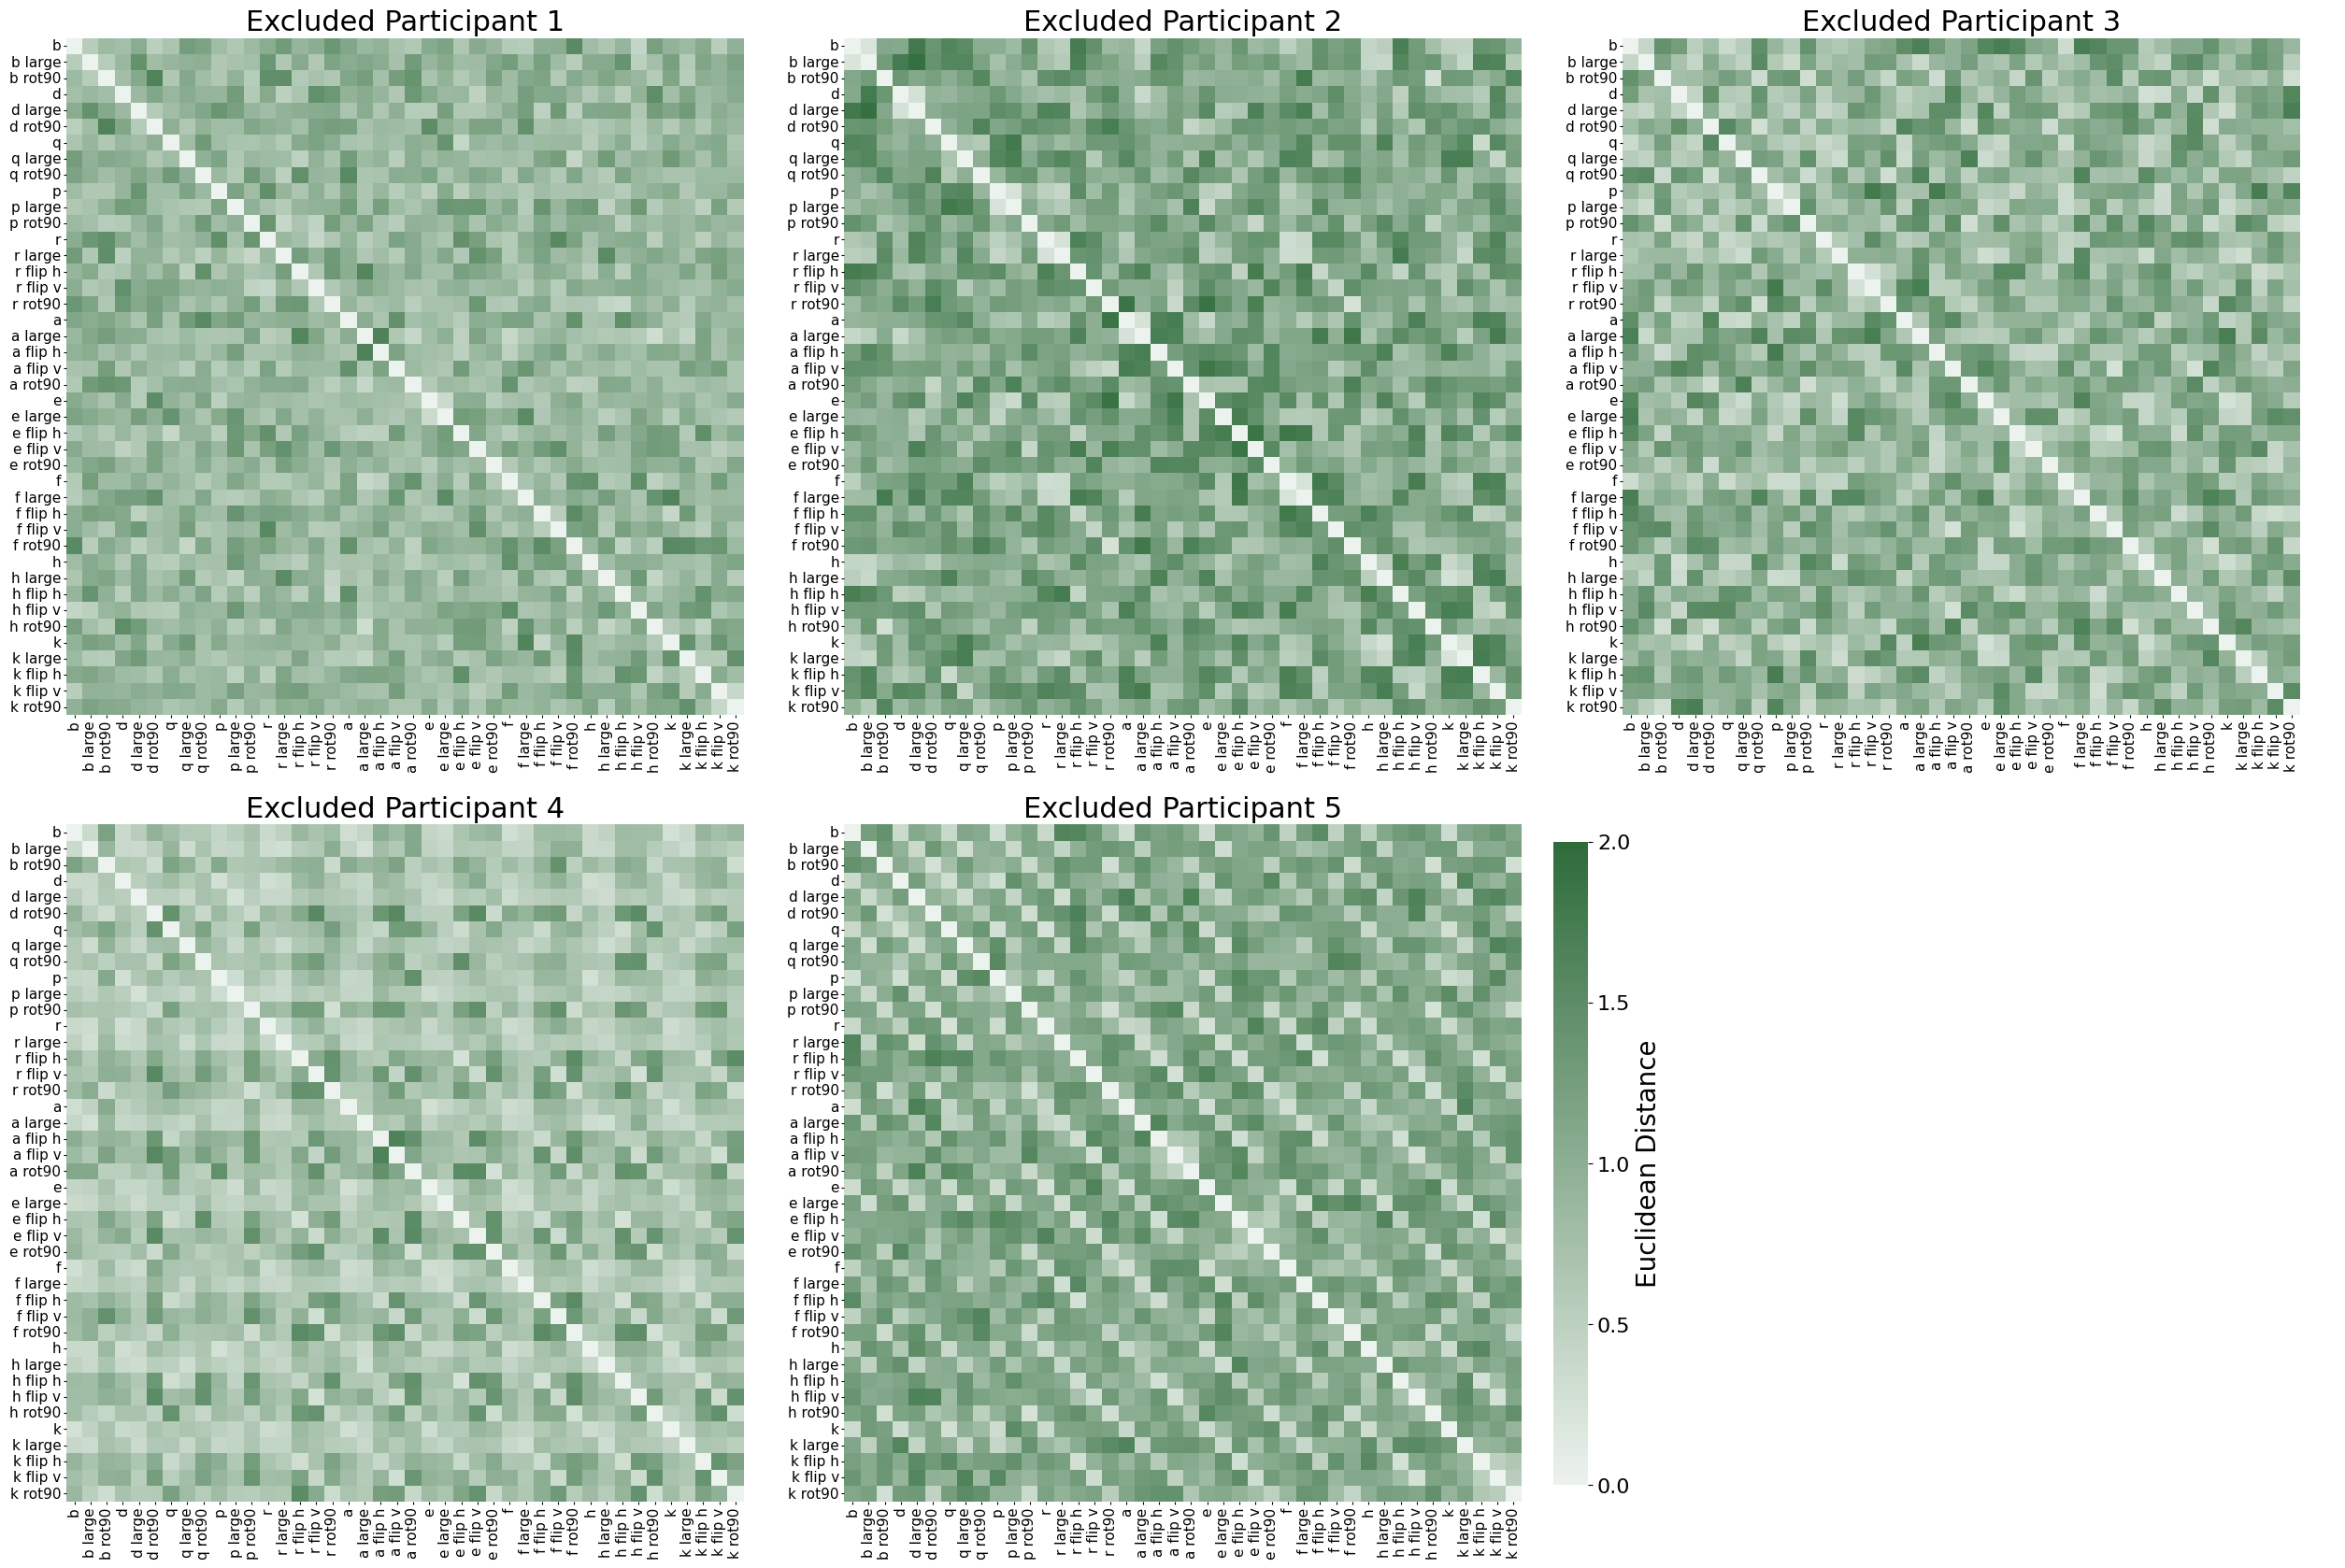

In [ ]:
RDMs_excl = []
excluded_names = []

os.makedirs(os.path.join(OUTPUT_PATH_FIGS, "excluded"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH_RDMS, "excluded"), exist_ok=True)

for path in data_files_excl:
    rdm_excl, stimulus_names_excl = compute_rdm_from_meadows(path, desired_order=ORDER)
    RDMs_excl.append(rdm_excl)
    excluded_names.append(os.path.basename(path).replace(".csv", ""))
    pd.DataFrame(rdm_excl, index=stimulus_names_excl, columns=stimulus_names_excl).to_csv(
        os.path.join(OUTPUT_PATH_RDMS, "excluded", f"{excluded_names[-1]}_rdm.csv")
    )

if len(RDMs_excl) > 0:
    vmin = min(np.min(rdm) for rdm in RDMs_excl)
    vmax = max(np.max(rdm) for rdm in RDMs_excl)

    n_labels             = len(clean_labels)
    TARGET_FONTSIZE      = 11
    LINE_SPACING_FACTOR  = 1.1
    USABLE_FRACTION      = 0.85
    label_fontsize       = TARGET_FONTSIZE
    required_heatmap_in  = (label_fontsize / 72) * LINE_SPACING_FACTOR * n_labels
    panel_size_in        = max(5.0, required_heatmap_in / USABLE_FRACTION)

    print(f"[label sizing] n_labels={n_labels}, fontsize={label_fontsize}pt -> panel size {panel_size_in:.1f}in")

    cmap_excl = sns.light_palette("#2e6b3a", as_cmap=True)
    n_cols, n_rows = 3, 2

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(panel_size_in * n_cols, panel_size_in * n_rows),
        sharex=False, sharey=False, squeeze=False, constrained_layout=True,
    )
    fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.01, wspace=0.01, hspace=0.03)

    panel_order = [0, 1, 2, 3, 4]
    axes_flat = axes.ravel()
    last_hm = last_ax = None

    for i, rdm_excl in enumerate(RDMs_excl):
        if i >= len(panel_order):
            break
        ax = axes_flat[panel_order[i]]
        hm = sns.heatmap(
            rdm_excl, ax=ax, cmap=cmap_excl, vmin=vmin, vmax=2,
            cbar=False, square=True,
            xticklabels=clean_labels, yticklabels=clean_labels,
        )
        last_hm, last_ax = hm, ax
        ax.set_title(f"Excluded Participant {i + 1}", fontsize=22, pad=6)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", va="top", fontsize=label_fontsize)
        ax.tick_params(axis="x", labelbottom=True, bottom=True, length=2, pad=2)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=label_fontsize)
        ax.tick_params(axis="y", left=True, labelleft=True, length=2, pad=2)

    used_idx = set(panel_order[: min(len(RDMs_excl), len(panel_order))])
    for j, ax in enumerate(axes_flat):
        if j not in used_idx:
            ax.axis("off")

    fig.canvas.draw()
    pos = last_ax.get_position()
    cbar_ax = fig.add_axes([pos.x1 + 0.012, pos.y0 + pos.height * 0.025, 0.015, pos.height * 0.95])
    cbar = fig.colorbar(last_hm.collections[0], cax=cbar_ax)
    cbar.outline.set_visible(False)
    cbar.set_label("Euclidean Distance", fontsize=20)
    cbar.set_ticks([0, 0.5, 1, 1.5, 2])
    cbar.ax.tick_params(labelsize=16)

    plt.savefig(
        os.path.join(OUTPUT_PATH_FIGS, "excluded", "excluded_participants_rdms_grid.png"),
        dpi=600, bbox_inches="tight",
    )
    plt.show()

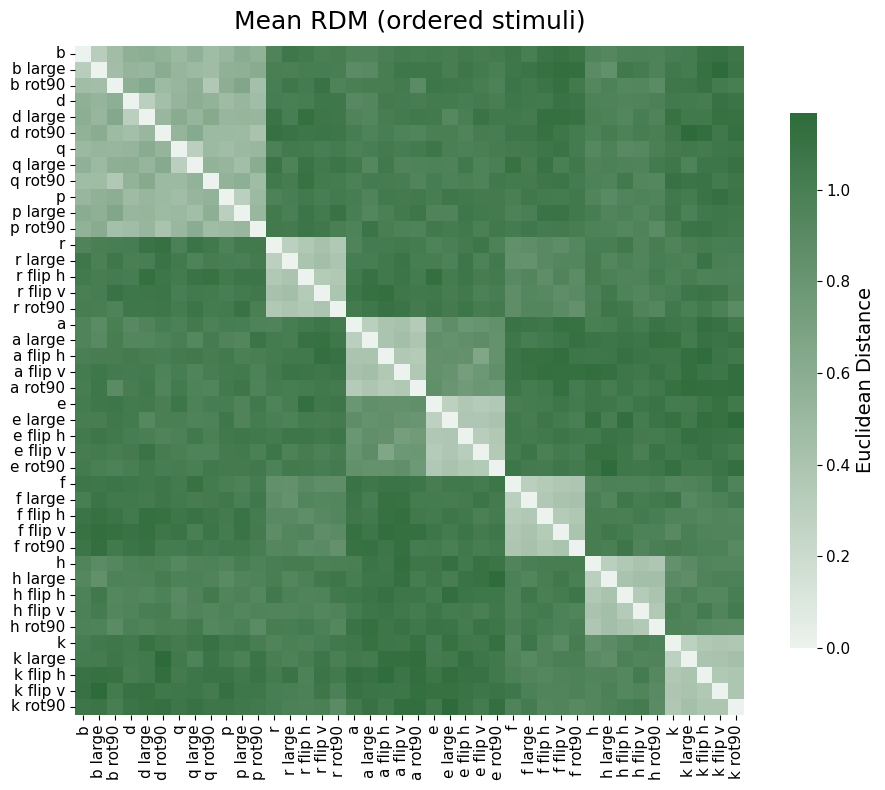

In [ ]:
# Match the green used in the later bar plots
cmap = sns.light_palette("#2e6b3a", as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 8))
hm = sns.heatmap(
    mean_rdm,
    cmap=cmap,
    xticklabels=clean_labels,
    yticklabels=clean_labels,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Mean RDM (ordered stimuli)", pad=12, fontsize=18)
ax.set_xlabel("")
ax.set_ylabel("")

# Make labels readable
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

cbar = hm.collections[0].colorbar
cbar.set_label("Euclidean Distance", fontsize=14)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_PATH_FIGS,
        "mean_rdm_ordered_stimuli.png",
    ),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

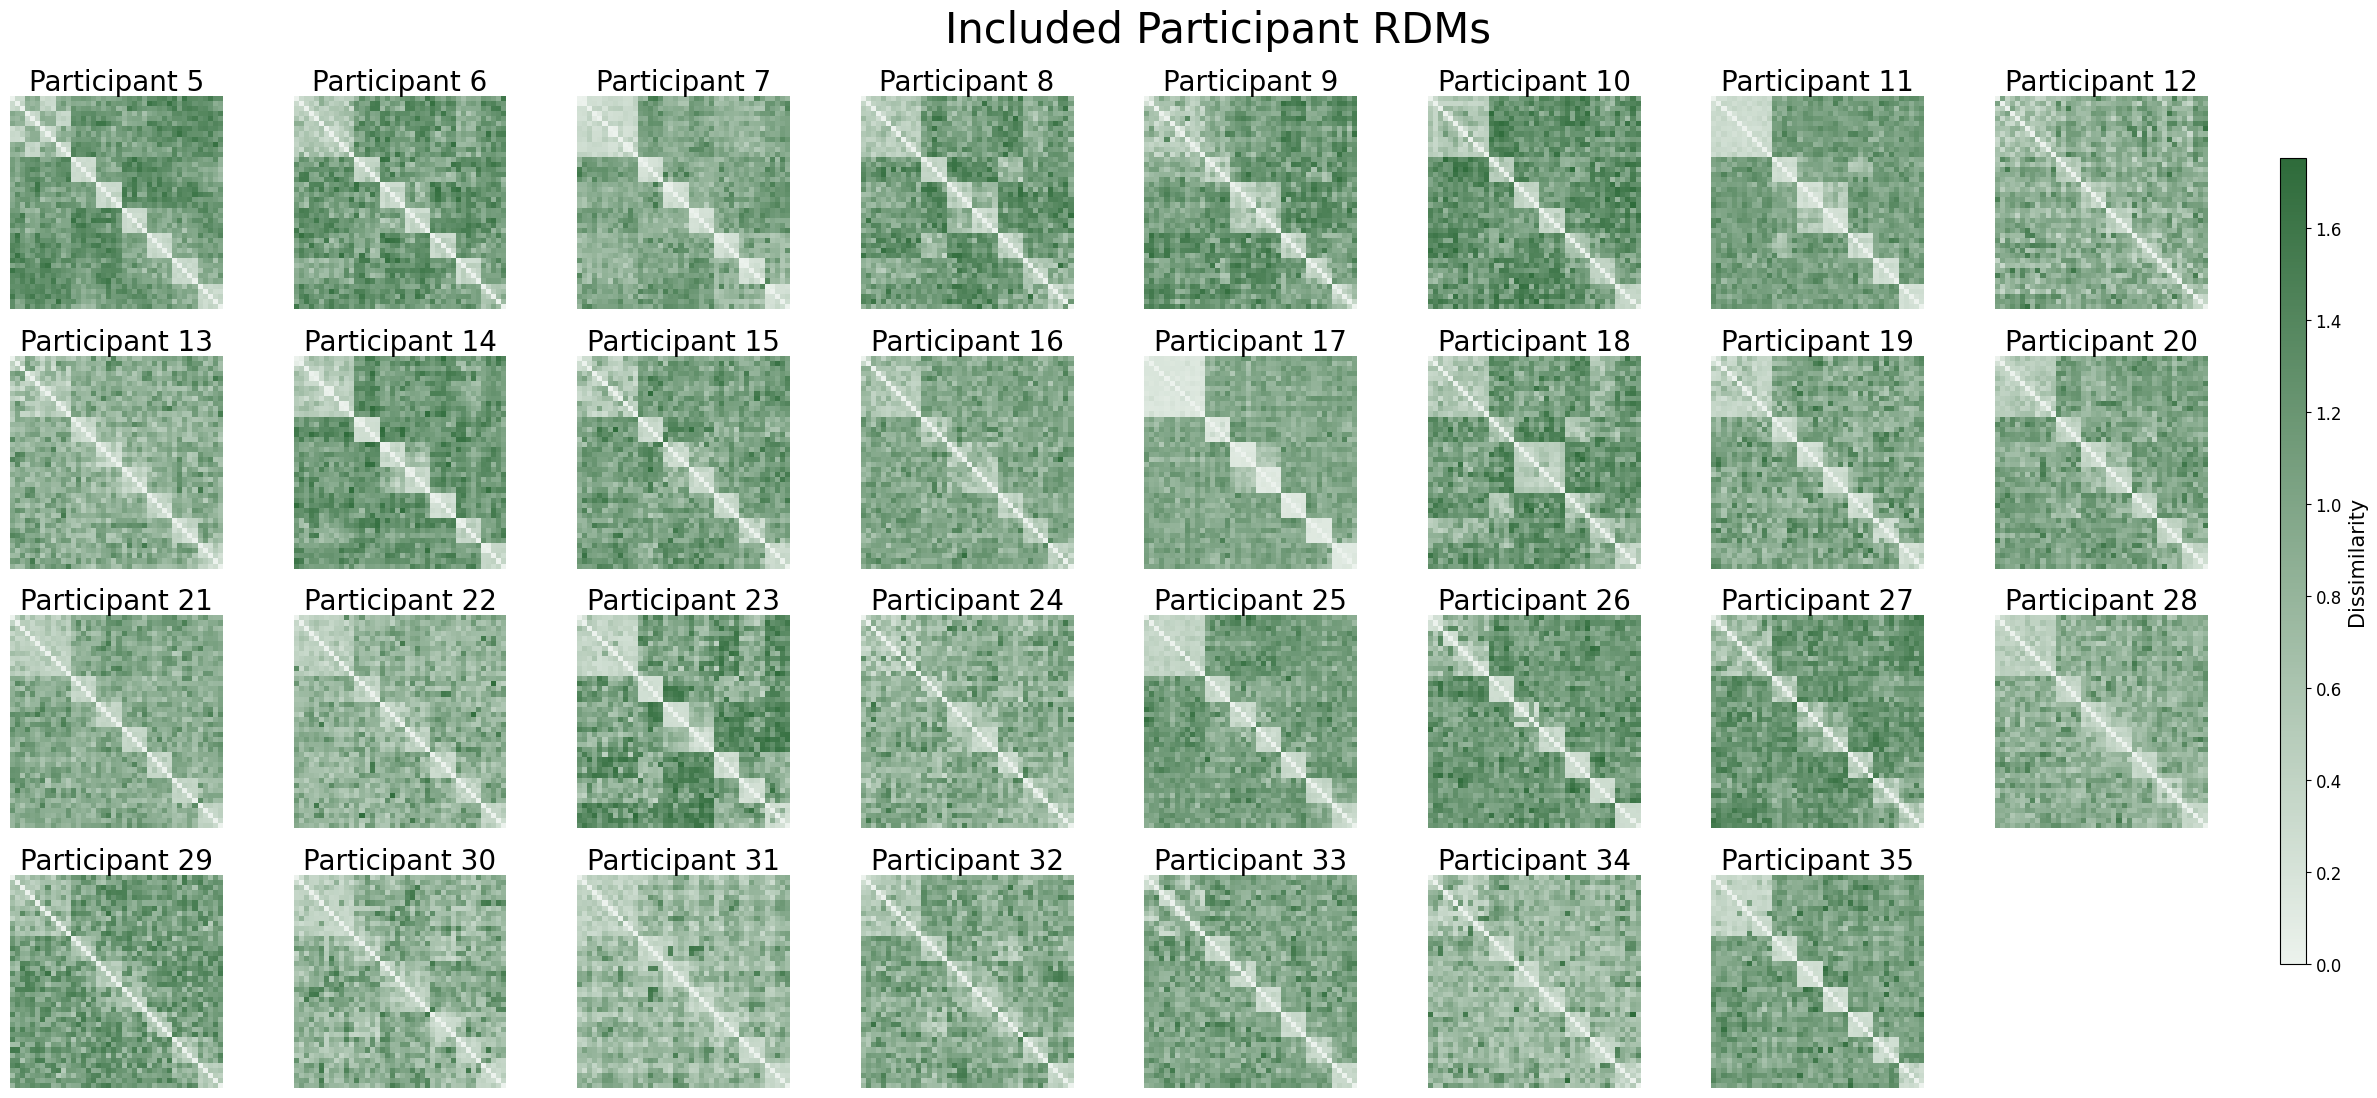

In [24]:
# Big grid plot of all participant RDMs (all participants, 8 columns)
n_rdms = len(RDMs)
n_cols = 8
n_rows = int(np.ceil(n_rdms / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.2 * n_cols, 3.1 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
axes = np.array(axes).reshape(n_rows, n_cols)

last_hm = None
for i, ax in enumerate(axes.flat):
    if i < n_rdms:
        hm = sns.heatmap(
            RDMs[i],
            ax=ax,
            cmap=cmap,
            vmin=0,
            vmax=np.max(RDMs),
            cbar=False,
            square=True,
            xticklabels=False,
            yticklabels=False,
        )
        last_hm = hm
        ax.set_title(f"Participant {i + 5}", fontsize=20, pad=4)
        ax.tick_params(left=False, bottom=False)
    else:
        ax.axis("off")

# Tighter left/right margins, more breathing room on top/bottom
fig.subplots_adjust(left=0.015, right=0.90, top=0.88, bottom=0.08, wspace=0.01, hspace=0.22)

# One shared colorbar in a smaller dedicated axis on the right (no overlap)
if last_hm is not None:
    cbar_ax = fig.add_axes([0.915, 0.18, 0.010, 0.65])
    cbar = fig.colorbar(last_hm.collections[0], cax=cbar_ax)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label("Dissimilarity", fontsize=15)

fig.suptitle("Included Participant RDMs", y=0.95, fontsize=30)
fig.savefig(
    os.path.join(
        OUTPUT_PATH_FIGS,
        "included_participants_rdms_grid.png",
    ),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

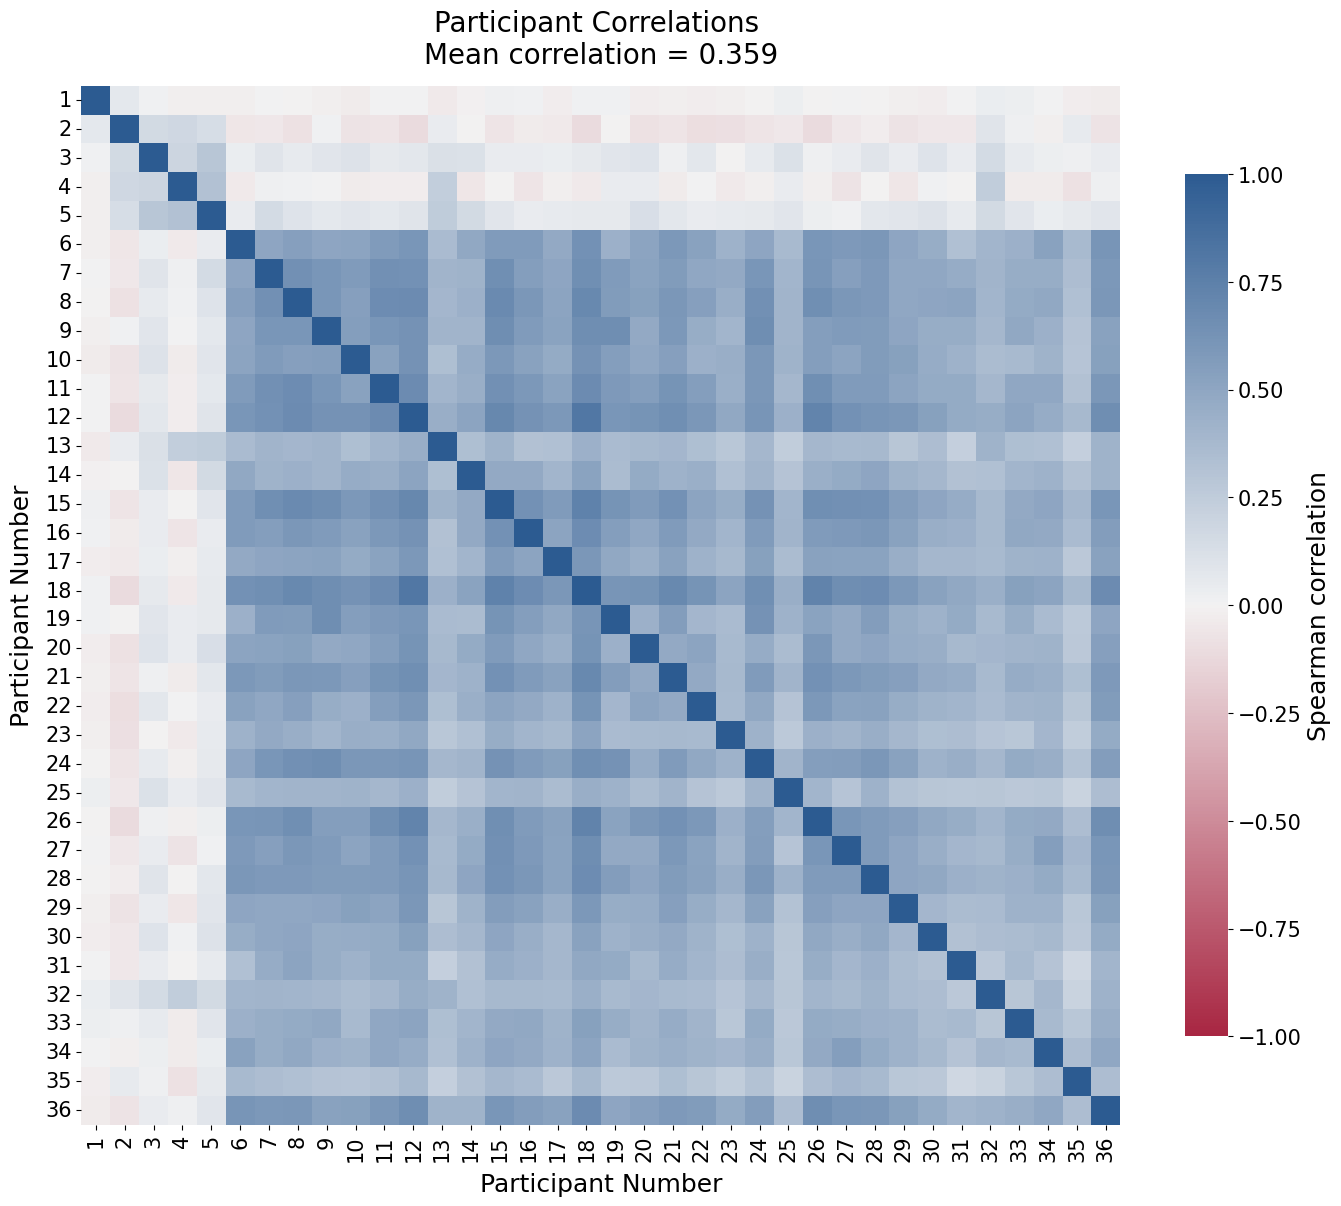

In [26]:
all_rdms = RDMs_excl + RDMs 
participant_labels = [str(i + 1) for i in range(len(all_rdms))]

# Vectorize upper triangle (excluding diagonal) for each RDM
tri_idx = np.triu_indices_from(all_rdms[0], k=1)
rdm_vectors = np.array([rdm[tri_idx] for rdm in all_rdms])

# Participant-by-participant correlation matrix
corr_matrix = np.corrcoef(rdm_vectors)

# Mean correlation excluding the diagonal
off_diag = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
mean_corr = off_diag.mean()
std_corr = off_diag.std()

# Darker, low-saturation diverging colormap: pink -> white -> blue
pastel_pink_blue = sns.diverging_palette(
    365, 250, s=80, l=38, center="light", as_cmap=True
)

fig, ax = plt.subplots(figsize=(14, 12))
hm = sns.heatmap(
    corr_matrix,
    cmap=pastel_pink_blue,
    vmin=-1,
    vmax=1,
    xticklabels=participant_labels,
    yticklabels=participant_labels,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Spearman correlation"},
    ax=ax
)

# Set all non-title text to 14
ax.set_xlabel("Participant Number", fontsize=18, labelpad=8)
ax.set_ylabel("Participant Number", fontsize=18, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=15)

# Title at 18
ax.set_title(
    f"Participant Correlations \nMean correlation = {mean_corr:.3f}",
    pad=16,
    fontsize=20,
)

# Colorbar font sizes
cbar = hm.collections[0].colorbar
cbar.set_label("Spearman correlation", fontsize=18)
cbar.ax.tick_params(labelsize=15)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PATH_FIGS, "participant_rdm_correlation_matrix.png"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

In [ ]:
rev_letters    = ["b", "d", "p", "q"]
rev_variants   = ["normal", "large", "normal_rot90"]
non_rev_letters = ["r", "a", "e", "f", "h", "k"]

rev_pair_map = {
    "horizontal":   [("b", "d"), ("p", "q")],
    "vertical":     [("b", "p"), ("d", "q")],
    "90° rotation": [("b", "q"), ("d", "p")],
}

bdpq_rows = []
non_rev_rows = []

for participant, rdm in enumerate(RDMs, start=1):
    # Reversible (bdpq) — mirror pairs across variants
    for pair_type, pairs in rev_pair_map.items():
        for letter_a, letter_b in pairs:
            for variant in rev_variants:
                stim_a, stim_b = f"{letter_a}_{variant}", f"{letter_b}_{variant}"
                if stim_a in stim_to_idx and stim_b in stim_to_idx:
                    bdpq_rows.append({
                        "participant": participant,
                        "pair_type": pair_type,
                        "dissimilarity": pair_distance(rdm, stim_to_idx, stim_a, stim_b),
                    })
    # Reversible — large variant
    for letter in rev_letters:
        stim_a, stim_b = f"{letter}_normal", f"{letter}_large"
        if stim_a in stim_to_idx and stim_b in stim_to_idx:
            bdpq_rows.append({
                "participant": participant,
                "pair_type": "large",
                "dissimilarity": pair_distance(rdm, stim_to_idx, stim_a, stim_b),
            })
    # Non-reversible — all four transformations
    for letter in non_rev_letters:
        for pair_type, stim_a, stim_b in [
            ("h-flip",       f"{letter}_normal", f"{letter}_normal_flip_h"),
            ("v-flip",       f"{letter}_normal", f"{letter}_normal_flip_v"),
            ("90° rotation", f"{letter}_normal", f"{letter}_normal_rot90"),
            ("large",        f"{letter}_normal", f"{letter}_large"),
        ]:
            if stim_a in stim_to_idx and stim_b in stim_to_idx:
                non_rev_rows.append({
                    "participant": participant,
                    "pair_type": pair_type,
                    "dissimilarity": pair_distance(rdm, stim_to_idx, stim_a, stim_b),
                })

bdpq_df    = pd.DataFrame(bdpq_rows)
non_rev_df = pd.DataFrame(non_rev_rows)

# Combine into a single comparable long-format dataframe
condition_order = ["horizontal", "vertical", "90° rotation", "large"]
class_order     = ["reversible", "non-reversible"]

condition_maps = {
    "reversible":     {c: c for c in condition_order},
    "non-reversible": {"h-flip": "horizontal", "v-flip": "vertical",
                       "90° rotation": "90° rotation", "large": "large"},
}

frames = []
for cls, src_df in [("reversible", bdpq_df), ("non-reversible", non_rev_df)]:
    col_map = condition_maps[cls]
    sub = src_df[src_df["pair_type"].isin(col_map)].copy()
    sub["condition"]    = sub["pair_type"].map(col_map)
    sub["letter_class"] = cls
    frames.append(sub[["participant", "condition", "letter_class", "dissimilarity"]])

combo_df = pd.concat(frames, ignore_index=True)
print(f"Built combo_df: {len(combo_df)} rows  ({len(bdpq_rows)} reversible, {len(non_rev_rows)} non-reversible).")

In [ ]:
# -- Plot 1 -- Reversible vs Non-Reversible (collapsed across conditions) --

summary_by_class = summarize_with_ci(combo_df, ["letter_class"])

fig, ax = plt.subplots(figsize=(7.5, 6), facecolor="white")

sns.barplot(
    data=combo_df,
    x="letter_class", y="dissimilarity", hue="letter_class",
    order=class_order, hue_order=class_order, palette=PALETTE,
    estimator=np.mean, errorbar=("ci", 95),
    width=BAR_WIDTH, capsize=CAPSIZE,
    err_kws={"color": "#1f2a1f", "linewidth": 1.2},
    ax=ax, dodge=False, legend=False,
)

apply_axes_style(ax, "Letter Class")
ax.set_xlim(-0.35, 1.35)
ax.set_title("Differences Reversibility (95% CI)", fontsize=TITLE_FONTSIZE, pad=13)

legend_handles = [
    Patch(facecolor=PALETTE["reversible"], edgecolor="none", label="reversible"),
    Patch(facecolor=PALETTE["non-reversible"], edgecolor="none", label="non-reversible"),
]
ax.legend(handles=legend_handles, title="", loc="upper right",
          bbox_to_anchor=(1.35, 0.95), fontsize=LEGEND_FONTSIZE,
          frameon=False, handletextpad=0.6)

# Paired t-test, reversible vs non-reversible, collapsed across all conditions
participant_class_means = (
    combo_df.groupby(["participant", "letter_class"], as_index=False)["dissimilarity"]
    .mean()
)
wide = participant_class_means.pivot(
    index="participant", columns="letter_class", values="dissimilarity"
).dropna()

if wide.shape[0] > 1:
    t_stat, p_val = ttest_rel(wide["reversible"], wide["non-reversible"])
else:
    t_stat, p_val = np.nan, np.nan

label = p_to_stars(p_val)
ymin, ymax = ax.get_ylim()
yrange = ymax - ymin if ymax > ymin else 1.0
y_base = summary_by_class["mean"].max() + summary_by_class["ci"].max() + 0.03 * yrange
h = 0.02 * yrange

draw_sig_bracket(ax, 0, 1, y_base, h, label, fontsize=ANNOTATION_FONTSIZE)
ax.set_ylim(ymin, ymax + 0.14 * yrange)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, "reversible_vs_nonreversible.png"), dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# -- Plot 2 -- Conditions Collapsed ----------------------------------------

condition_summary = summarize_with_ci(combo_df, ["condition"])

# Pairwise stats: each non-large condition vs "large"
participant_condition_means = (
    combo_df.groupby(["participant", "condition"], as_index=False)["dissimilarity"].mean()
)
non_large_conditions = [c for c in condition_order if c != "large"]
pairwise_results = []

for cond_a in non_large_conditions:
    cond_b = "large"
    wide_pair = (
        participant_condition_means[participant_condition_means["condition"] == cond_a]
        .set_index("participant")
        .join(
            participant_condition_means[participant_condition_means["condition"] == cond_b]
            .set_index("participant"),
            lsuffix="_a", rsuffix="_b",
        )
        .dropna()
    )
    if wide_pair.shape[0] > 1:
        t_stat_pair, p_pair = ttest_rel(wide_pair["dissimilarity_a"], wide_pair["dissimilarity_b"])
        pairwise_results.append({
            "Comparison": f"{cond_a} vs {cond_b}",
            "cond_a": cond_a, "cond_b": cond_b,
            "t_stat": float(t_stat_pair), "p_raw": float(p_pair),
            "n": int(wide_pair.shape[0]),
        })

if pairwise_results:
    _, pvals_holm_pair, _, _ = multipletests(
        [r["p_raw"] for r in pairwise_results], alpha=0.05, method="holm"
    )
    for r, p_holm in zip(pairwise_results, pvals_holm_pair):
        r["p_holm"] = float(p_holm)
        r["label"] = p_to_stars(float(p_holm))

fig, ax = plt.subplots(figsize=(7.5, 6), facecolor="white")

sns.barplot(
    data=combo_df,
    x="condition", y="dissimilarity",
    order=condition_order, color=PALETTE_SINGLE,
    estimator=np.mean, errorbar=("ci", 95),
    width=BAR_WIDTH, capsize=CAPSIZE,
    err_kws={"color": "#1f2a1f", "linewidth": 1.2},
    ax=ax,
)

apply_axes_style(ax, "Transformation Condition")
ax.set_title("Dissimilarity Across Transformations (95% CI)", fontsize=TITLE_FONTSIZE, pad=13)

# Significance brackets
sig_pairs = sorted(
    [r for r in pairwise_results if r.get("label", "n.s.") != "n.s."],
    key=lambda r: abs(condition_order.index(r["cond_b"]) - condition_order.index(r["cond_a"])),
)
bar_tops = {row["condition"]: row["mean"] + row["ci"] for _, row in condition_summary.iterrows()}
ymin, ymax = ax.get_ylim()
yrange = (ymax - ymin) or 1.0
step = 0.09 * yrange
bracket_heights = {}


def get_bracket_y(i_a, i_b):
    max_y = max(bar_tops.get(condition_order[i_a], 0),
                bar_tops.get(condition_order[i_b], 0)) + 0.03 * yrange
    for (k_a, k_b), y in bracket_heights.items():
        if k_a <= i_b and k_b >= i_a:
            max_y = max(max_y, y + step)
    return max_y


h = 0.015 * yrange
for r in sig_pairs:
    i_a, i_b = condition_order.index(r["cond_a"]), condition_order.index(r["cond_b"])
    y_base = get_bracket_y(i_a, i_b)
    bracket_heights[(i_a, i_b)] = y_base
    draw_sig_bracket(ax, i_a, i_b, y_base, h, r["label"], fontsize=ANNOTATION_FONTSIZE, text_gap=0.004 * yrange)

if bracket_heights:
    max_bracket = max(bracket_heights.values()) + step + 0.02 * yrange
    ax.set_ylim(ymin, max(ymax, max_bracket) + 0.04 * yrange)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, "conditions_collapsed.png"), dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# -- Plot 3 -- Reversible vs Non-Reversible across Transformations ---------

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")

sns.barplot(
    data=combo_df,
    x="condition", y="dissimilarity", hue="letter_class",
    order=condition_order, hue_order=class_order, palette=PALETTE,
    estimator=np.mean, errorbar=("ci", 95),
    width=0.8, capsize=0.1,
    err_kws={"color": "#1f2a1f", "linewidth": 1.2},
    ax=ax, dodge=True,
)

apply_axes_style(ax, "Transformation Condition")
ax.set_title(
    "Reversible vs Non-Reversible Letters Across Transformations (95% CI)",
    pad=12, fontsize=TITLE_FONTSIZE,
)
ax.legend(title="", loc="upper right", bbox_to_anchor=(1.0, 0.95),
          fontsize=LEGEND_FONTSIZE, frameon=False)

# Paired t-tests per condition, Holm-corrected across conditions
results = paired_ttest_groups(
    combo_df, group_col="condition", class_col="letter_class",
    class_a="reversible", class_b="non-reversible",
    group_values=condition_order,
)
sig_by_cond = {r["condition"]: r for r in results}

ymin, ymax = ax.get_ylim()
yrange = (ymax - ymin) or 1.0

for i, cond in enumerate(condition_order):
    mean_rev, ci_rev = mean_ci(combo_df, cond, "reversible")
    mean_non, ci_non = mean_ci(combo_df, cond, "non-reversible")
    if pd.isna(mean_rev) or pd.isna(mean_non):
        continue
    y_base = max(mean_rev + ci_rev, mean_non + ci_non) + 0.03 * yrange
    h = 0.02 * yrange
    draw_sig_bracket(ax, i - 0.2, i + 0.2, y_base, h, sig_by_cond[cond]["label"], fontsize=ANNOTATION_FONTSIZE)

ax.set_ylim(ymin, ymax + 0.12 * yrange)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, "reversible_vs_nonreversible_conditions.png"), dpi=600)
plt.show()